# Telecom Customer Churn Prediction
## Indian Telecom Market — Classification Project

> **Problem Statement:** Indian telecom companies spend significantly more retaining existing customers than acquiring new ones (retention cost ~Rs.800-1500 vs acquisition ~Rs.3000-5000 per customer). Goal: predict which customers are likely to churn so retention teams can intervene proactively.

> **Business Impact:** A 5% improvement in churn prediction can save crores by targeting only high-risk customers.

---

### Notebook Structure
| Section | What Happens |
|---------|-------------|
| 1. Setup & Load | Import libraries, load data |
| 2. EDA | Understand data, find patterns |
| 3. Preprocessing | Clean, encode, scale |
| 4. Feature Engineering | Create meaningful new features |
| 5. Feature Selection | Pick what matters |
| 6. Model Building | Train multiple classifiers |
| 7. Hyperparameter Tuning | Optimize best models |
| 8. Final Evaluation | Compare, pick winner |
| 9. Business Insights | Translate model output to action |

## Section 1 — Setup & Data Loading

**What we do here:** Import all required libraries and load the dataset.

**Questions to answer:**
- How many rows and columns?
- What are the data types of each column?
- Is the target variable `Churn` already present?
- Are there any immediately visible issues?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('All libraries imported successfully')

All libraries imported successfully


In [5]:
df = pd.read_csv('telecom_india_churn.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nData Types:\n{df.dtypes}')
df.head()

Shape: (7043, 21)

Columns: ['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure_Months', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
CustomerID           object
Gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
Tenure_Months         int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure_Months,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,IND-00001,Male,0,No,No,37,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),62.50,2208.31,No
1,IND-00002,Female,1,Yes,No,31,Yes,No,DSL,No,...,Yes,No,No,Yes,Month-to-month,No,Electronic check,112.49,3758.58,Yes
2,IND-00003,Female,0,Yes,Yes,49,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,28.88,1442.56,No
3,IND-00004,Female,0,No,No,53,Yes,No,DSL,No,...,Yes,No,No,Yes,One year,No,Mailed check,54.30,3205.15,No
4,IND-00005,Male,0,No,No,39,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),107.57,4042.38,Yes


---
## Section 2 — Exploratory Data Analysis (EDA)

**Why EDA matters:** You cannot model what you do not understand.

**Key Questions:**
1. What is the churn rate? Is the dataset imbalanced?
2. Which customer segment churns the most? (Contract? Internet? Senior Citizens?)
3. How does tenure relate to churn?
4. Are high monthly charges associated with higher churn?
5. Does payment method matter?
6. Are there null values or quality issues?

> **Insight to look for:** Month-to-month + Fiber optic + short tenure = highest churn risk. This is the danger-zone customer profile.

In [6]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure_Months     7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

,SeniorCitizen,Tenure_Months,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.159875,36.651001,68.784224,2520.011213
std,0.366516,20.982391,28.428053,1878.377905
min,0.000000,1.000000,20.010000,20.970000
25%,0.000000,18.000000,44.190000,1009.040000
50%,0.000000,37.000000,68.450000,2092.120000
75%,0.000000,55.000000,92.865000,3718.210000
max,1.000000,72.000000,118.990000,8819.820000


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
# Question: Are any columns missing data? How will you handle them?

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


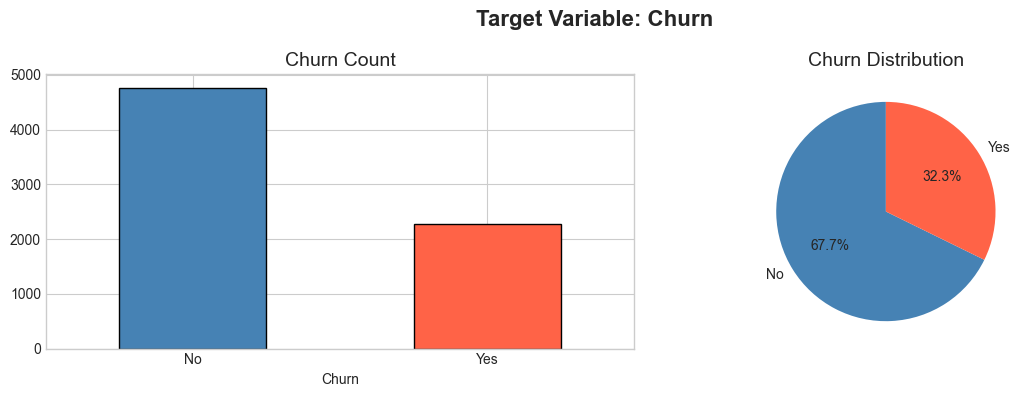

Churn Rate: 32.26%
Check: Is this imbalanced? If >70% one class, consider SMOTE or class_weight


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14)
axes[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.suptitle('Target Variable: Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

churn_rate = df['Churn'].value_counts(normalize=True)['Yes']
print(f'Churn Rate: {churn_rate:.2%}')
print('Check: Is this imbalanced? If >70% one class, consider SMOTE or class_weight')

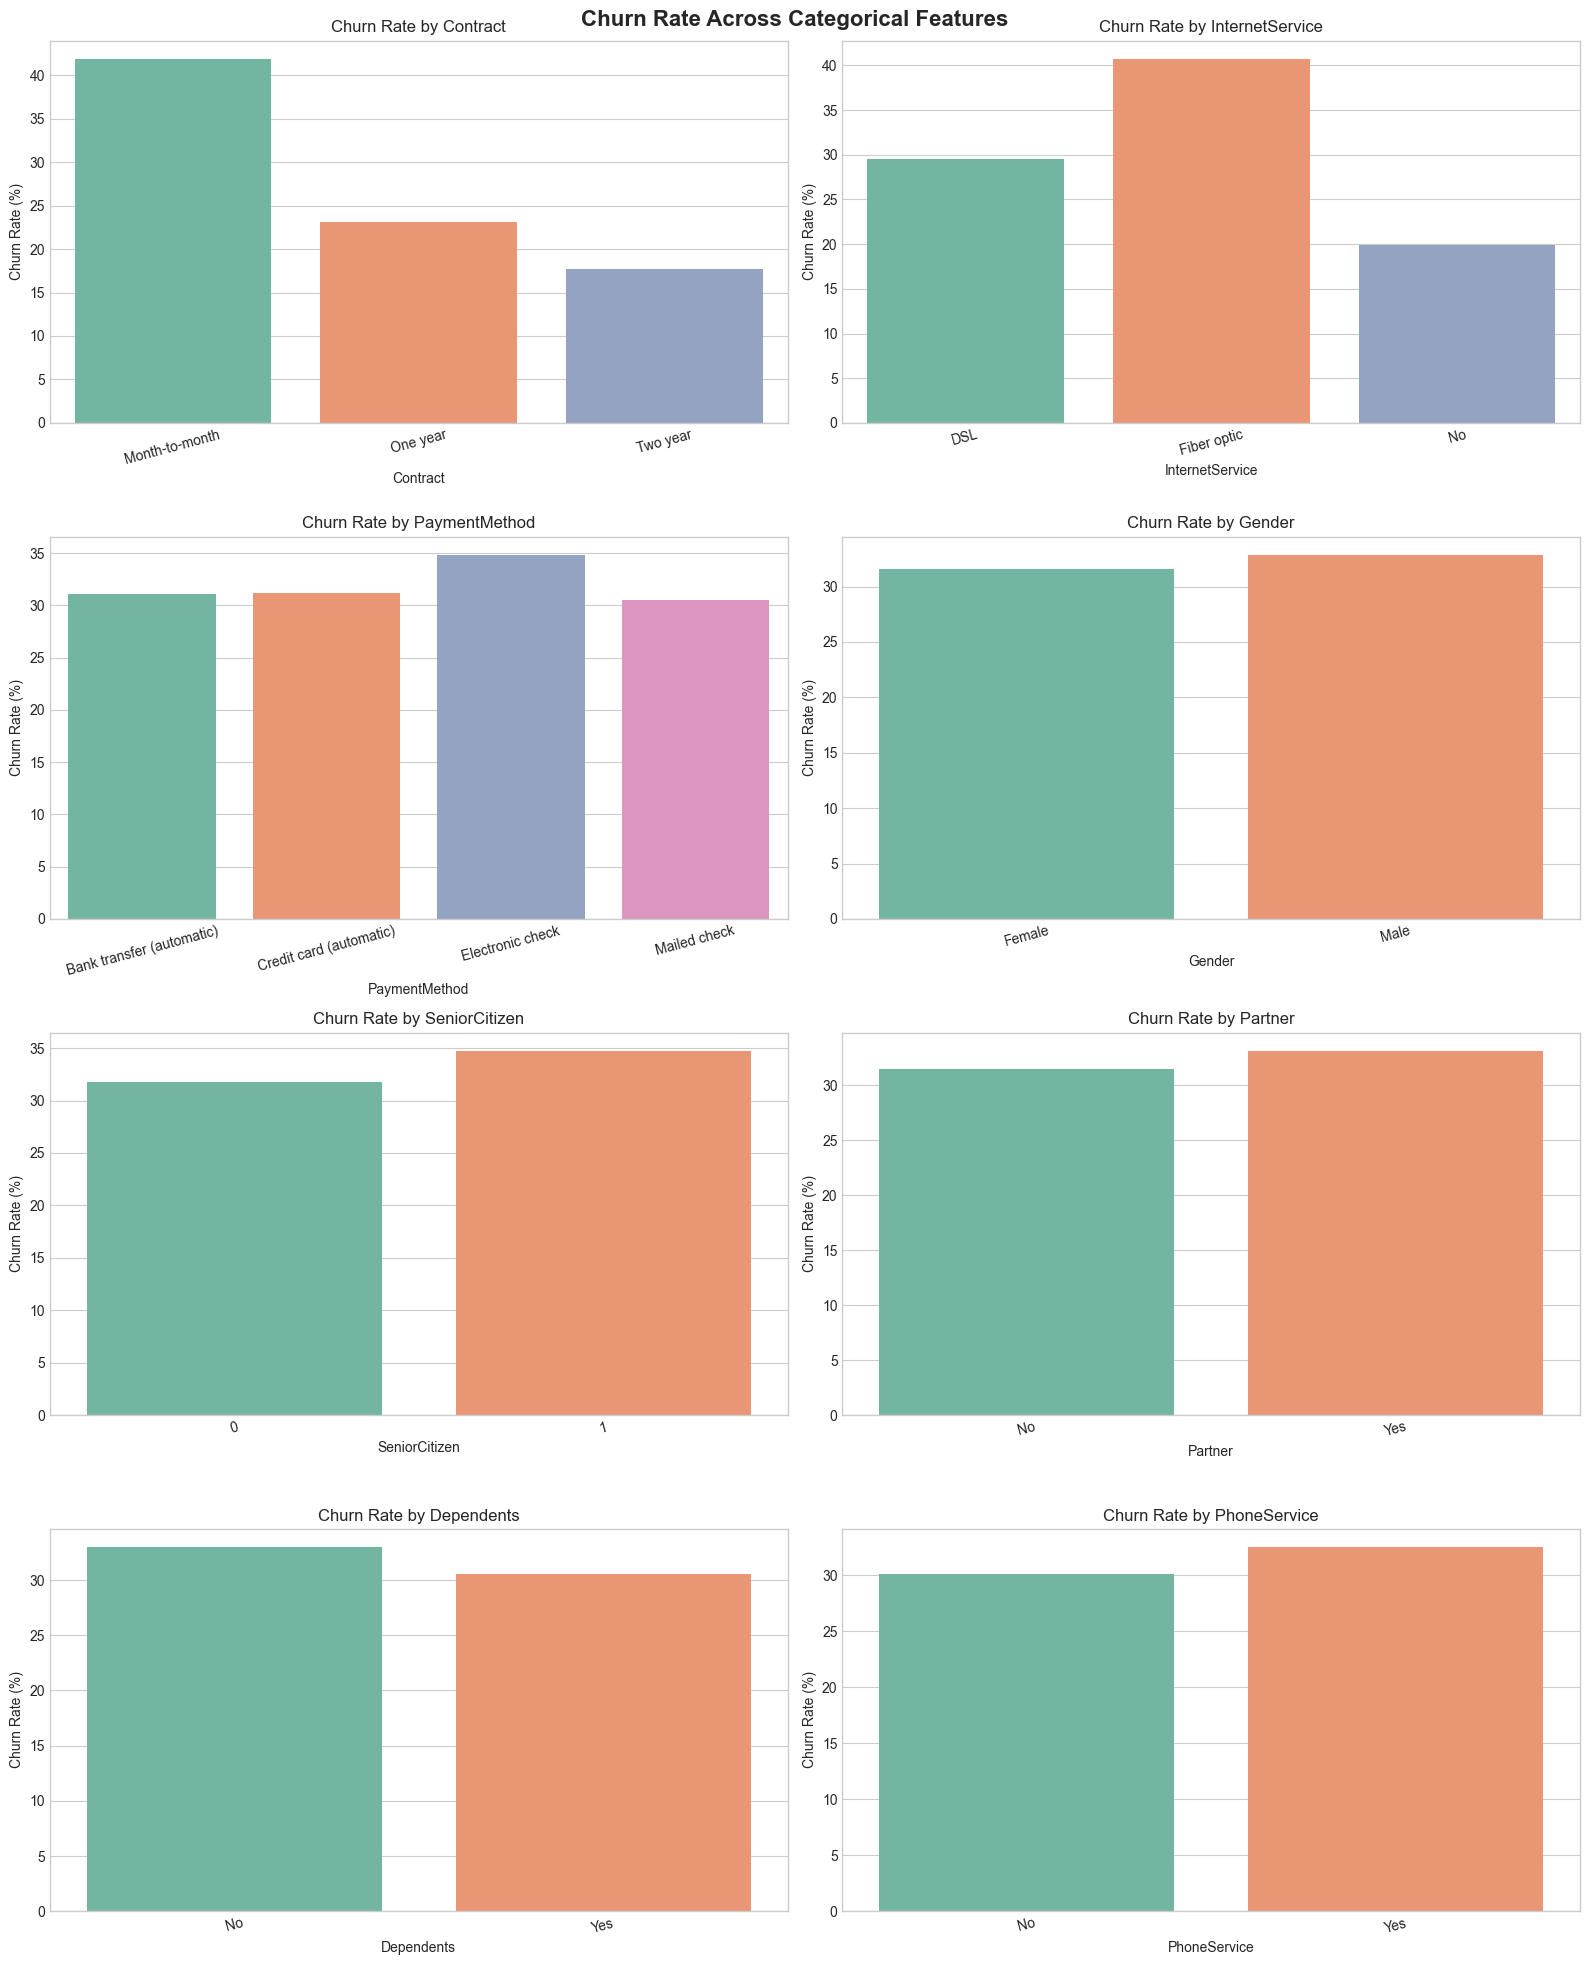

In [9]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'Gender',
            'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    sns.barplot(x=col, y='Churn_Rate', data=churn_rate, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn Rate Across Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# Note: Which category has highest churn in each feature?

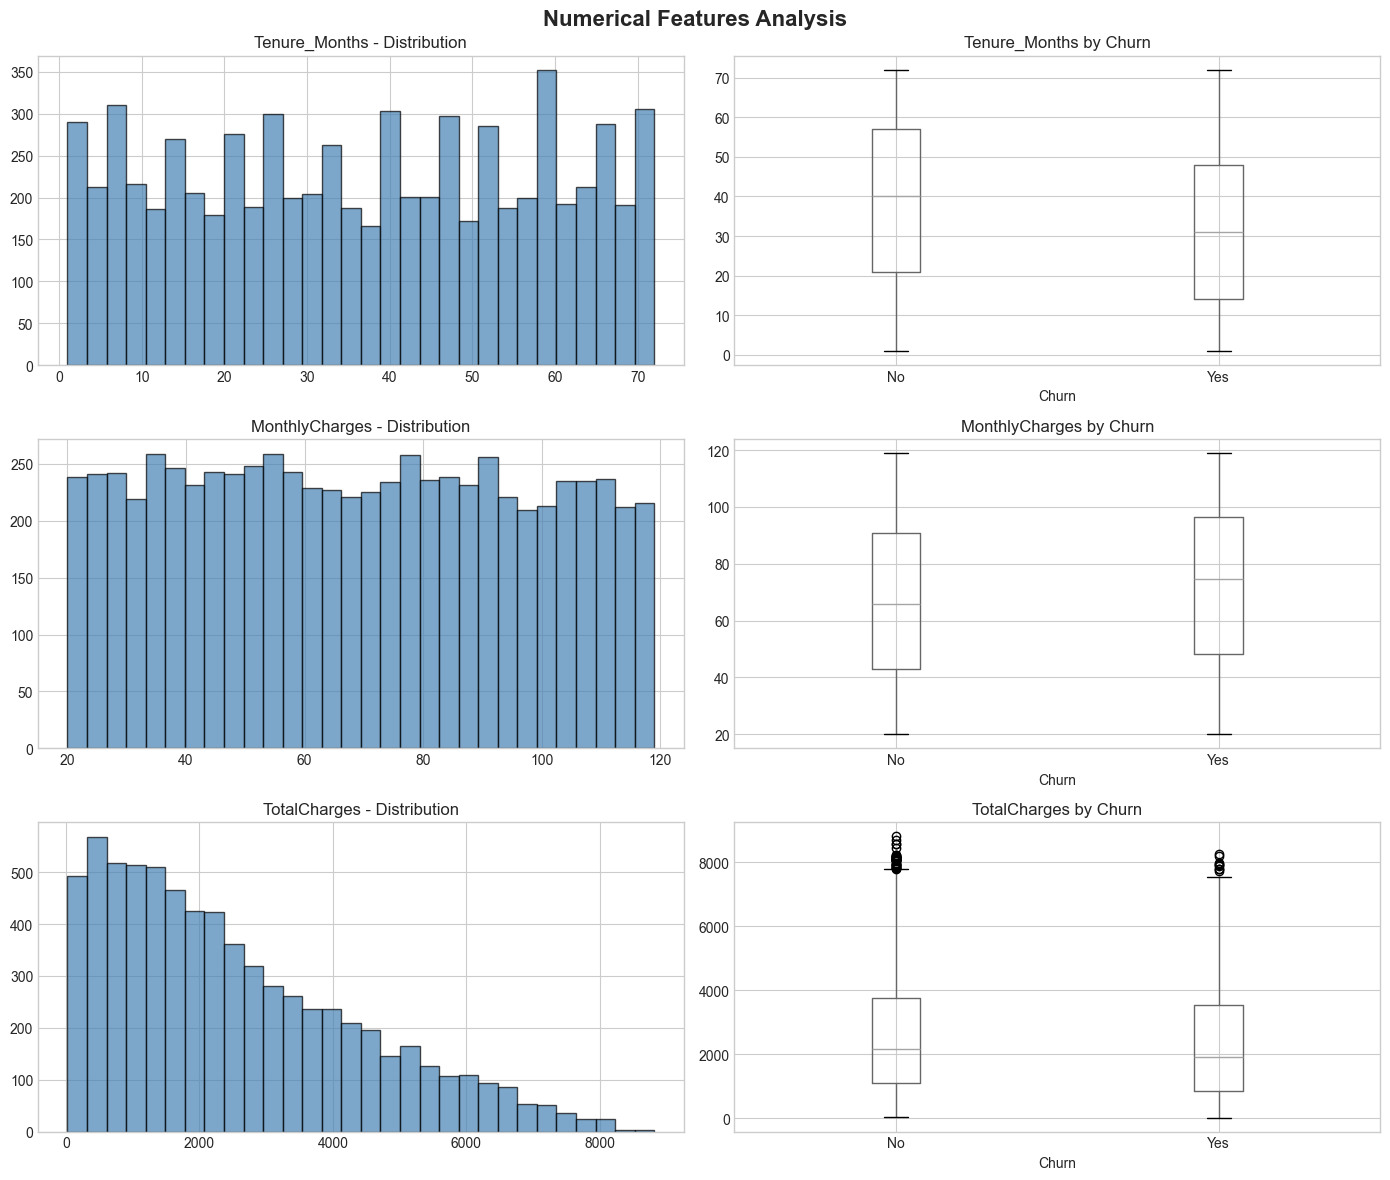

In [10]:
num_cols = ['Tenure_Months', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(num_cols):
    df[col].hist(bins=30, ax=axes[i][0], color='steelblue', edgecolor='black', alpha=0.7)
    axes[i][0].set_title(f'{col} - Distribution')
    df.boxplot(column=col, by='Churn', ax=axes[i][1])
    axes[i][1].set_title(f'{col} by Churn')

plt.suptitle('Numerical Features Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# Questions: Are features skewed? Do churners have shorter tenure? Higher charges?

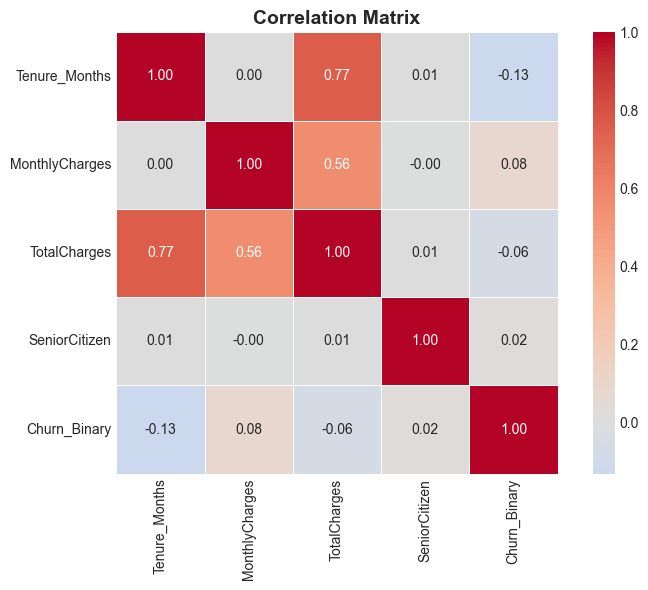

In [11]:
df_temp = df.copy()
df_temp['Churn_Binary'] = (df_temp['Churn'] == 'Yes').astype(int)
corr_cols = ['Tenure_Months', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Binary']
corr_matrix = df_temp[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Watch: TotalCharges and Tenure_Months might be highly correlated (multicollinearity)

---
## Section 3 — Data Preprocessing

**What we do here:**
1. Handle missing values
2. Drop irrelevant columns (CustomerID adds zero predictive value)
3. Encode categorical variables
4. Train-Test Split (Stratified — preserves churn ratio in both sets)
5. Feature Scaling

**Key Rules:**
- Use One-Hot Encoding for nominal categories (no order), Label Encoding for binary
- **Never fit scaler on full dataset before split — that is data leakage**
- Tree-based models (RF, XGBoost, LightGBM) do NOT need scaling

In [12]:
df_clean = df.drop(columns=['CustomerID'])
print(f'Shape after dropping ID: {df_clean.shape}')

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
print('Missing values handled')

Shape after dropping ID: (7043, 20)
Missing values handled


In [13]:
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print('Target encoded: Yes=1, No=0')
print(df_clean['Churn'].value_counts())

Target encoded: Yes=1, No=0
Churn
0    4771
1    2272
Name: count, dtype: int64


In [14]:
binary_cols = ['Gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

print(f'Shape after encoding: {df_clean.shape}')

Shape after encoding: (7043, 31)


In [15]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate: {y_test.mean():.2%}')

Train size: (5634, 30), Test size: (1409, 30)
Train churn rate: 32.25%
Test churn rate: 32.29%


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
print('Scaling done. Fit on train only — no data leakage.')
print('Note: tree-based models (RF, XGB, LGBM) can use unscaled X_train/X_test directly')

Scaling done. Fit on train only — no data leakage.
Note: tree-based models (RF, XGB, LGBM) can use unscaled X_train/X_test directly


---
## Section 4 — Feature Engineering

**What we do here:** Create new meaningful features that raw data does not capture.

| New Feature | Logic | Why |
|-------------|-------|-----|
| AvgMonthlySpend | TotalCharges / Tenure_Months | True average spend |
| TenureGroup | Bin tenure into buckets | Lifecycle stage |
| NumServices | Count active services | Engagement proxy |
| HasStreaming | TV or Movies = Yes | Stickiness indicator |
| IsHighValue | MonthlyCharges > 75th percentile | High-value flag |

New features created:
   AvgMonthlySpend          TenureGroup  NumServices  HasStreaming  \
0        58.113421  Established (2-4yr)            3             1   
1       117.455625  Established (2-4yr)            3             1   
2        28.851200         Loyal (4+yr)            1             0   
3        59.354630         Loyal (4+yr)            3             1   
4       101.059500  Established (2-4yr)            2             0   

   IsHighValue  
0            0  
1            1  
2            0  
3            0  
4            1  


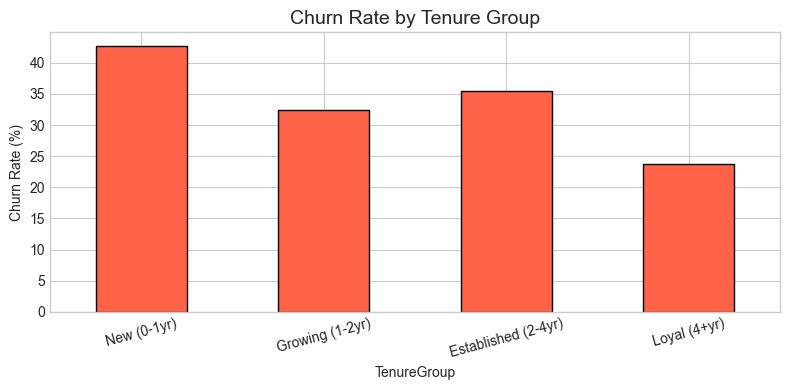

In [17]:
df_fe = df.copy()
df_fe['Churn'] = df_fe['Churn'].map({'Yes': 1, 'No': 0})
df_fe['TotalCharges'] = pd.to_numeric(df_fe['TotalCharges'], errors='coerce').fillna(0)

df_fe['AvgMonthlySpend'] = df_fe['TotalCharges'] / (df_fe['Tenure_Months'] + 1)

df_fe['TenureGroup'] = pd.cut(
    df_fe['Tenure_Months'], bins=[0, 12, 24, 48, 72],
    labels=['New (0-1yr)', 'Growing (1-2yr)', 'Established (2-4yr)', 'Loyal (4+yr)']
)

service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['NumServices'] = df_fe[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

df_fe['HasStreaming'] = ((df_fe['StreamingTV'] == 'Yes') | (df_fe['StreamingMovies'] == 'Yes')).astype(int)

threshold = df_fe['MonthlyCharges'].quantile(0.75)
df_fe['IsHighValue'] = (df_fe['MonthlyCharges'] > threshold).astype(int)

print('New features created:')
print(df_fe[['AvgMonthlySpend', 'TenureGroup', 'NumServices', 'HasStreaming', 'IsHighValue']].head())

churn_by_tenure = df_fe.groupby('TenureGroup')['Churn'].mean() * 100
churn_by_tenure.plot(kind='bar', color='tomato', edgecolor='black', figsize=(8, 4))
plt.title('Churn Rate by Tenure Group', fontsize=14)
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## Section 5 — Feature Selection

**Why Feature Selection?** Too many features leads to overfitting, slower training, and noise.

**Methods:**
1. Correlation Analysis — drop features correlated >0.90 with each other
2. Feature Importance from RandomForest — most intuitive for tabular data
3. Keep top N features based on importance scores

> You do not need all methods. RandomForest importance is the most reliable and explainable for interviews.

In [18]:
import numpy as np
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if val > 0.85:
            high_corr_pairs.append((col, row, val))

print('High correlation pairs (>0.85):')
for c1, c2, val in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {c1} <-> {c2}: {val:.3f}')
# Decision: If TotalCharges and Tenure highly correlated, drop TotalCharges

High correlation pairs (>0.85):
  MultipleLines_No phone service <-> PhoneService: 1.000
  OnlineSecurity_No internet service <-> InternetService_No: 1.000
  OnlineBackup_No internet service <-> InternetService_No: 1.000
  OnlineBackup_No internet service <-> OnlineSecurity_No internet service: 1.000
  DeviceProtection_No internet service <-> InternetService_No: 1.000
  DeviceProtection_No internet service <-> OnlineSecurity_No internet service: 1.000
  DeviceProtection_No internet service <-> OnlineBackup_No internet service: 1.000
  TechSupport_No internet service <-> InternetService_No: 1.000
  TechSupport_No internet service <-> OnlineSecurity_No internet service: 1.000
  TechSupport_No internet service <-> OnlineBackup_No internet service: 1.000
  TechSupport_No internet service <-> DeviceProtection_No internet service: 1.000
  StreamingTV_No internet service <-> InternetService_No: 1.000
  StreamingTV_No internet service <-> OnlineSecurity_No internet service: 1.000
  StreamingTV

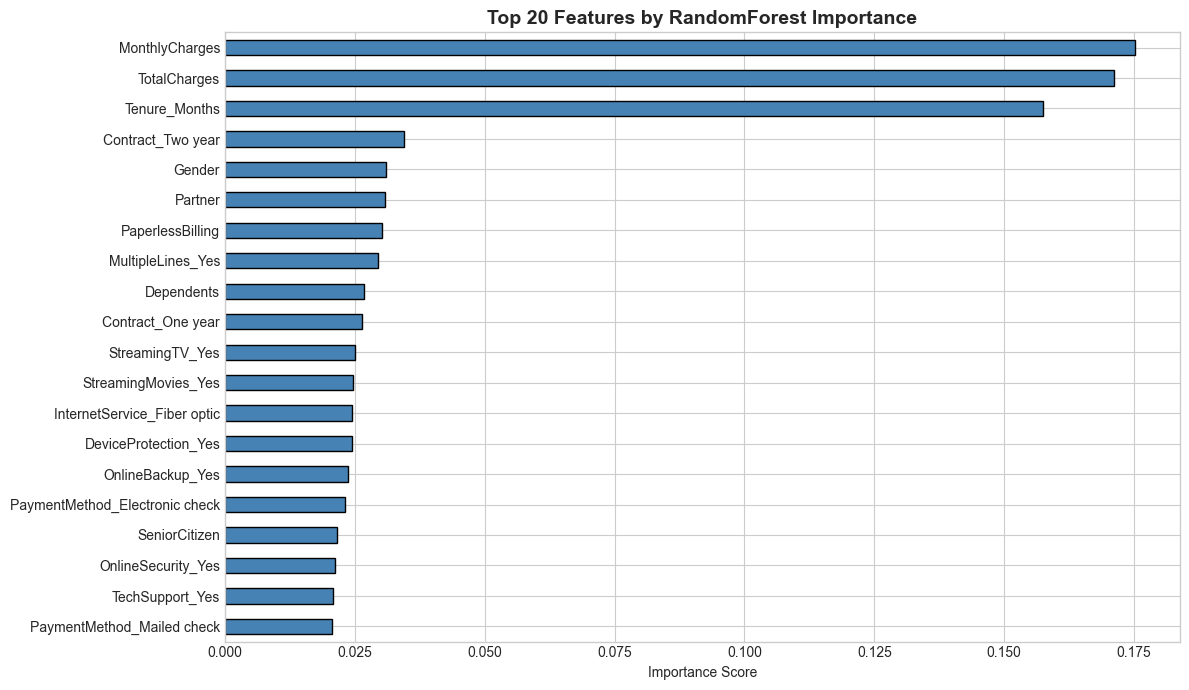

Top 10 most important features:
MonthlyCharges       0.175098
TotalCharges         0.171091
Tenure_Months        0.157422
Contract_Two year    0.034461
Gender               0.031030
Partner              0.030826
PaperlessBilling     0.030237
MultipleLines_Yes    0.029375
Dependents           0.026838
Contract_One year    0.026462
dtype: float64


In [19]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

feature_importance = pd.Series(rf_selector.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_importance.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Features by RandomForest Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(feature_importance.head(10))

In [20]:
top_n = 20  # Adjust based on your importance plot
top_features = feature_importance.head(top_n).index.tolist()

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]
X_train_scaled_sel = X_train_scaled[top_features]
X_test_scaled_sel = X_test_scaled[top_features]

print(f'Selected {top_n} features')
print(f'Shape after selection: {X_train_sel.shape}')

Selected 20 features
Shape after selection: (5634, 20)


---
## Section 6 — Model Building (Baseline)

**Strategy:** Train multiple models with default settings. Compare. Tune only top 2-3.

| Model | Type | Needs Scaling? |
|-------|------|---------------|
| Logistic Regression | Linear | Yes |
| Decision Tree | Tree | No |
| Random Forest | Ensemble Bagging | No |
| Gradient Boosting | Ensemble Boosting | No |
| AdaBoost | Ensemble Boosting | No |
| XGBoost | Ensemble Boosting | No |
| LightGBM | Ensemble Boosting | No |
| KNN | Distance-based | Yes |
| Naive Bayes | Probabilistic | No |

> **Metric Priority for Churn:**
> 1. **Recall** — missing a churner (False Negative) is more costly than false alarms
> 2. **ROC-AUC** — overall discriminating power
> 3. **F1-Score** — balance when classes are imbalanced

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
}

scaled_models = ['Logistic Regression', 'KNN']
print(f'Total models: {len(models)}')

Total models: 9


In [22]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_scaled_sel if name in scaled_models else X_train_sel
    X_te = X_test_scaled_sel if name in scaled_models else X_test_sel
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Model                                                                 
AdaBoost               0.6934     0.5556  0.2527    0.3474   0.7023   
Logistic Regression    0.6920     0.5493  0.2571    0.3503   0.7000   
Gradient Boosting      0.6891     0.5392  0.2571    0.3482   0.6990   
Naive Bayes            0.6941     0.5373  0.3802    0.4453   0.6975   
LightGBM               0.6828     0.5159  0.2857    0.3678   0.6856   
Random Forest          0.6856     0.5291  0.2396    0.3298   0.6694   
XGBoost                0.6735     0.4926  0.3648    0.4192   0.6465   
KNN                    0.6416     0.4150  0.2681    0.3258   0.5980   
Decision Tree          0.5919     0.3750  0.3956    0.3850   0.5406   

                     CV F1 (mean)  CV F1 (std)  
Model                                           
AdaBoost                   0.3721       0.0253  
Logistic Regression        0.3705       0.0258  
Gradient Boosting     

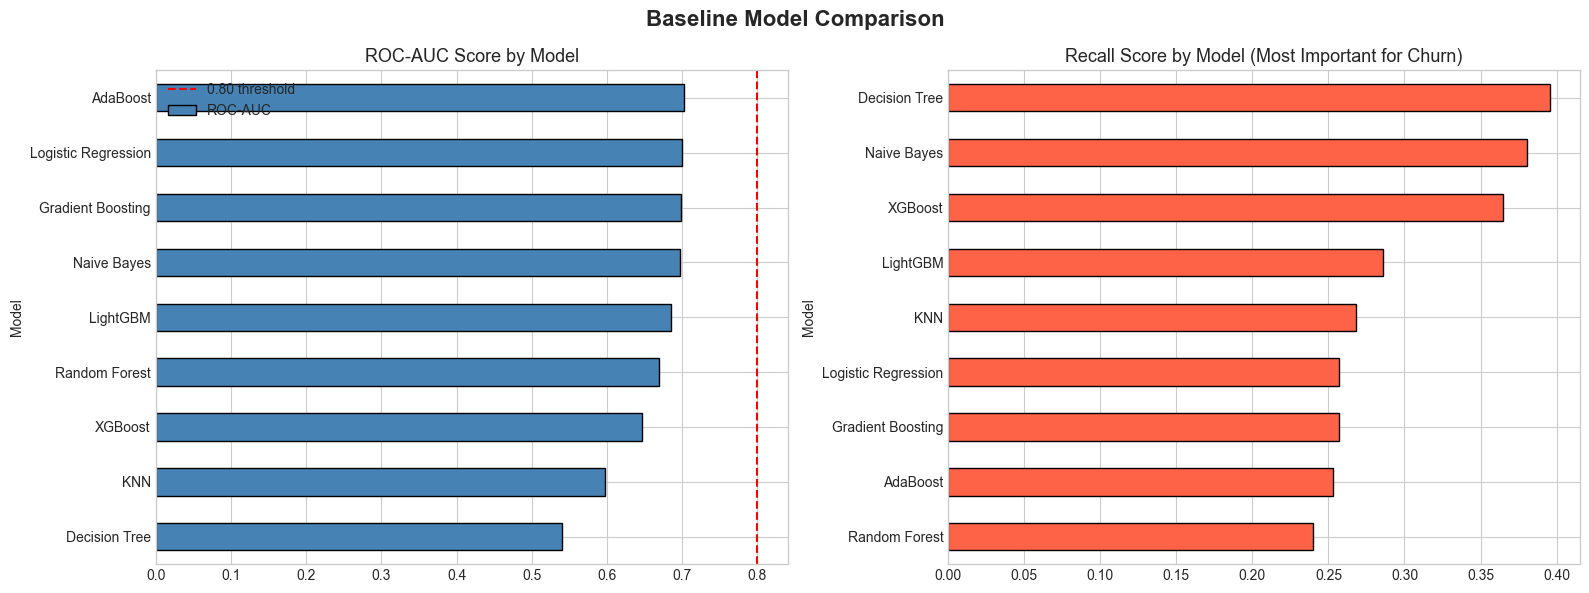

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
results_df['ROC-AUC'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('ROC-AUC Score by Model', fontsize=13)
axes[0].axvline(x=0.8, color='red', linestyle='--', label='0.80 threshold')
axes[0].legend()

results_df['Recall'].sort_values().plot(kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Recall Score by Model (Most Important for Churn)', fontsize=13)

plt.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

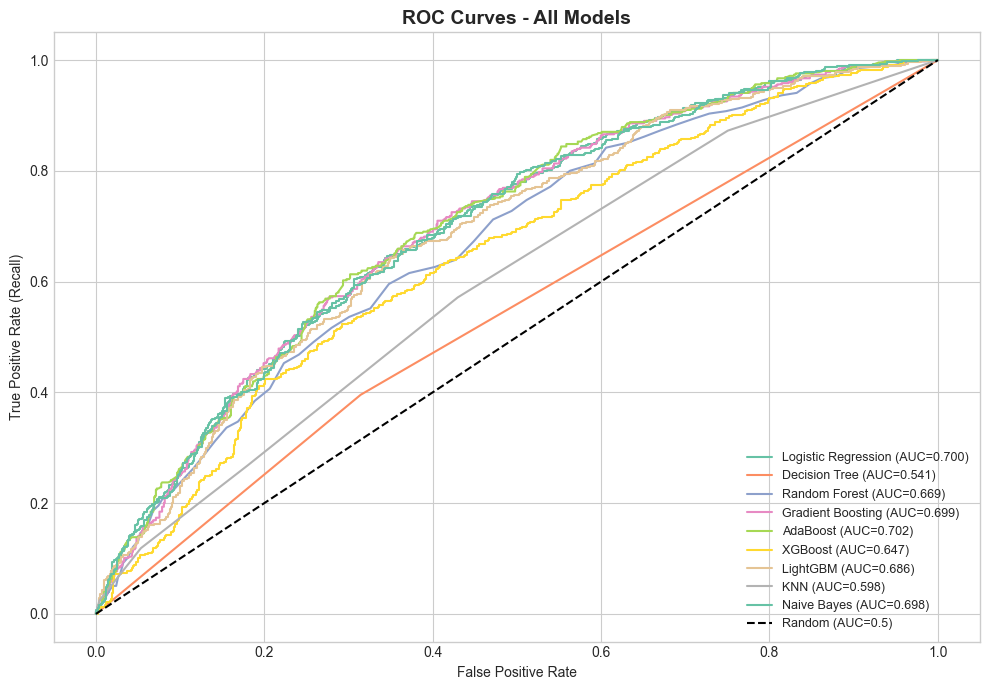

In [24]:
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if not hasattr(model, 'predict_proba'): continue
    X_te = X_test_scaled_sel if name in scaled_models else X_test_sel
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 7 — Hyperparameter Tuning

**Take the top 2-3 models from baseline and tune their hyperparameters.**

**Methods:**
- `GridSearchCV` — exhaustive, finds best in grid, slower
- `RandomizedSearchCV` — faster, samples from distributions, good for large spaces

**Models to tune:** XGBoost, LightGBM, Random Forest

> **Critical Rule:** Always tune on TRAINING data with cross-validation. Never touch test data during tuning.

In [25]:
from scipy.stats import randint, uniform

xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'scale_pos_weight': [1, 2, 3]
}

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
xgb_random = RandomizedSearchCV(
    xgb_model, param_distributions=xgb_param_dist, n_iter=50,
    scoring='roc_auc', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)
xgb_random.fit(X_train_sel, y_train)
print(f'Best XGBoost Params: {xgb_random.best_params_}')
print(f'Best CV ROC-AUC: {xgb_random.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost Params: {'colsample_bytree': np.float64(0.628376366799971), 'gamma': np.float64(0.1983919136069442), 'learning_rate': np.float64(0.02523055931181908), 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 242, 'scale_pos_weight': 2, 'subsample': np.float64(0.6375927759363476)}
Best CV ROC-AUC: 0.6901


In [26]:
lgbm_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 100),
    'min_child_samples': randint(10, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
lgbm_random = RandomizedSearchCV(
    lgbm_model, param_distributions=lgbm_param_dist, n_iter=50,
    scoring='roc_auc', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)
lgbm_random.fit(X_train_sel, y_train)
print(f'Best LightGBM Params: {lgbm_random.best_params_}')
print(f'Best CV ROC-AUC: {lgbm_random.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best LightGBM Params: {'colsample_bytree': np.float64(0.6553412369671205), 'learning_rate': np.float64(0.03654908444859396), 'max_depth': 4, 'min_child_samples': 39, 'n_estimators': 246, 'num_leaves': 36, 'subsample': np.float64(0.7595283605779178)}
Best CV ROC-AUC: 0.6917


In [27]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    rf_model, param_grid=rf_param_grid, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_sel, y_train)
print(f'Best RF Params: {rf_grid.best_params_}')
print(f'Best CV ROC-AUC: {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.6894


---
## Section 8 — Final Model Evaluation & Selection

**What we do here:**
1. Compare all tuned models on the held-out test set
2. Analyze confusion matrices
3. Find optimal classification threshold
4. Pick final model with clear written justification

**Decision Criteria for Churn:**
| Priority | Metric | Why |
|----------|--------|-----|
| 1st | Recall | False Negatives = lost customers = costly |
| 2nd | ROC-AUC | Overall discriminating power |
| 3rd | F1-Score | Balance when classes are imbalanced |

> **Threshold Tuning:** Lower threshold from 0.5 to 0.3-0.4 increases Recall (catches more churners) at the cost of some Precision. Usually the right business tradeoff.

In [28]:
tuned_models = {
    'XGBoost (Tuned)': xgb_random.best_estimator_,
    'LightGBM (Tuned)': lgbm_random.best_estimator_,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print('=== Tuned Model Performance ===')
print(tuned_df.round(4))

=== Tuned Model Performance ===
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                
LightGBM (Tuned)         0.6977     0.5633  0.2835    0.3772   0.6975
Random Forest (Tuned)    0.6600     0.4768  0.5429    0.5077   0.6948
XGBoost (Tuned)          0.6473     0.4640  0.5956    0.5217   0.6914


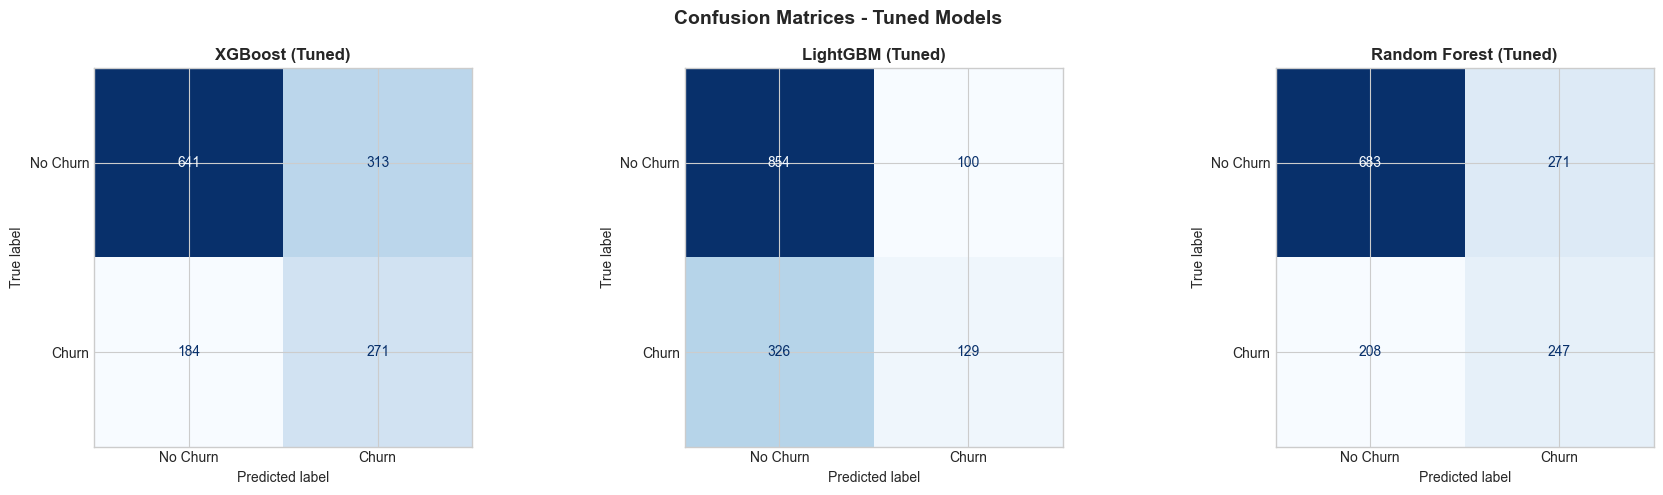

Confusion Matrix Interpretation:
  Top-Left  = True Negatives  (correctly predicted no churn)
  Top-Right = False Positives (predicted churn, actually stayed - wasted retention spend)
  Bot-Left  = False Negatives (missed churner - COSTLY)
  Bot-Right = True Positives  (correctly caught churner)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Tuned Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Confusion Matrix Interpretation:')
print('  Top-Left  = True Negatives  (correctly predicted no churn)')
print('  Top-Right = False Positives (predicted churn, actually stayed - wasted retention spend)')
print('  Bot-Left  = False Negatives (missed churner - COSTLY)')
print('  Bot-Right = True Positives  (correctly caught churner)')

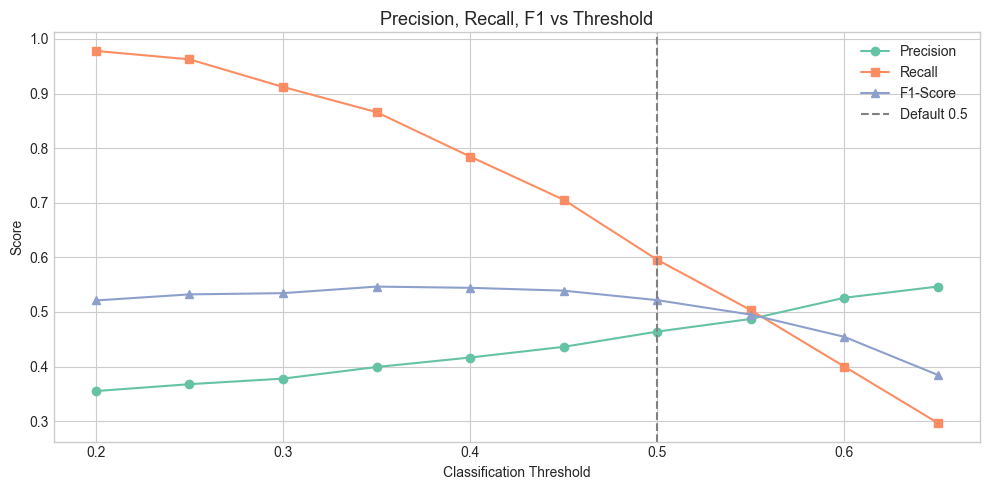

 Threshold  Precision   Recall       F1
      0.20   0.355148 0.978022 0.521077
      0.25   0.367758 0.962637 0.532199
      0.30   0.377960 0.912088 0.534449
      0.35   0.399189 0.865934 0.546463
      0.40   0.416569 0.784615 0.544207
      0.45   0.436141 0.705495 0.539043
      0.50   0.464041 0.595604 0.521655
      0.55   0.487234 0.503297 0.495135
      0.60   0.526012 0.400000 0.454432
      0.65   0.546559 0.296703 0.384615


In [30]:
best_model = xgb_random.best_estimator_
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.2, 0.7, 0.05)
thresh_results = []
for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    thresh_results.append({
        'Threshold': round(thresh, 2),
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })

thresh_df = pd.DataFrame(thresh_results)
plt.figure(figsize=(10, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', marker='o')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], label='Recall', marker='s')
plt.plot(thresh_df['Threshold'], thresh_df['F1'], label='F1-Score', marker='^')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
print(thresh_df.to_string(index=False))

In [31]:
FINAL_THRESHOLD = 0.40  # Adjust based on threshold analysis above
y_final_pred = (y_prob_best >= FINAL_THRESHOLD).astype(int)

print(f'=== Final Model: XGBoost (threshold={FINAL_THRESHOLD}) ===\n')
print(classification_report(y_test, y_final_pred, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}')

=== Final Model: XGBoost (threshold=0.4) ===

              precision    recall  f1-score   support

    No Churn       0.82      0.48      0.60       954
       Churn       0.42      0.78      0.54       455

    accuracy                           0.58      1409
   macro avg       0.62      0.63      0.57      1409
weighted avg       0.69      0.58      0.58      1409

ROC-AUC: 0.6914


---
## Section 9 — Business Insights & Actionable Recommendations

**Translating Model Output to Business Action**

This is what separates a data scientist from someone who just runs models. The model is done — now tell the business what to do.

**Key Deliverables:**
1. High-risk customer list (churn probability > threshold)
2. Top churn drivers translated into business language
3. Segment-specific retention strategies

In [32]:
churn_proba = best_model.predict_proba(X_test_sel)[:, 1]

output_df = X_test.copy().reset_index(drop=True)
output_df['Churn_Probability'] = churn_proba
output_df['Churn_Predicted'] = (churn_proba >= FINAL_THRESHOLD).astype(int)
output_df['Risk_Level'] = pd.cut(
    churn_proba, bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print('Customer Risk Segmentation:')
print(output_df['Risk_Level'].value_counts())
print('\nTop 10 Highest Risk Customers:')
output_df.sort_values('Churn_Probability', ascending=False).head(10)[['Churn_Probability', 'Risk_Level']]

Customer Risk Segmentation:
Risk_Level
Medium       514
High         448
Low          311
Very High    136
Name: count, dtype: int64

Top 10 Highest Risk Customers:


,Churn_Probability,Risk_Level
175,0.860862,Very High
370,0.860258,Very High
1338,0.856462,Very High
750,0.853263,Very High
48,0.846244,Very High
1154,0.835512,Very High
507,0.830097,Very High
1310,0.826004,Very High
955,0.823581,Very High
368,0.818304,Very High


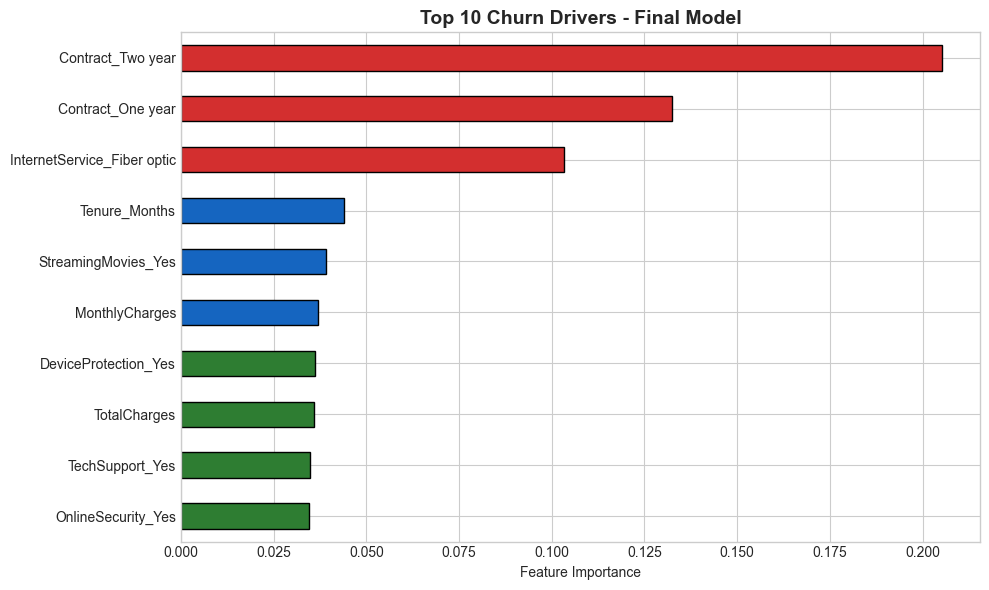


=== Business Interpretation ===

HIGH IMPACT Churn Drivers (Red bars - Top 3):
  Month-to-month contracts: No long-term commitment -> easy to leave
  Short tenure: New customers (0-12 months) have not built loyalty yet
  High monthly charges: Price-sensitive customers seek cheaper alternatives

MEDIUM IMPACT Drivers (Blue bars):
  No online security / tech support: Customers feel underserved
  Fiber optic without add-ons: High-paying but underserved segment

RETENTION STRATEGIES:
  1. Offer contract upgrade discounts at 6-month mark for month-to-month customers
  2. Create onboarding loyalty program for first 90 days (highest churn window)
  3. Bundle security + tech support for fiber optic customers as free add-on
  4. Targeted win-back campaigns for high-charges + no security profile


In [33]:
final_importance = pd.Series(
    best_model.feature_importances_, index=X_train_sel.columns
).sort_values(ascending=False).head(10)

colors = ['#d32f2f' if i < 3 else '#1565c0' if i < 6 else '#2e7d32' for i in range(10)]
plt.figure(figsize=(10, 6))
final_importance.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 10 Churn Drivers - Final Model', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

business_insights = [
    '',
    '=== Business Interpretation ===',
    '',
    'HIGH IMPACT Churn Drivers (Red bars - Top 3):',
    '  Month-to-month contracts: No long-term commitment -> easy to leave',
    '  Short tenure: New customers (0-12 months) have not built loyalty yet',
    '  High monthly charges: Price-sensitive customers seek cheaper alternatives',
    '',
    'MEDIUM IMPACT Drivers (Blue bars):',
    '  No online security / tech support: Customers feel underserved',
    '  Fiber optic without add-ons: High-paying but underserved segment',
    '',
    'RETENTION STRATEGIES:',
    '  1. Offer contract upgrade discounts at 6-month mark for month-to-month customers',
    '  2. Create onboarding loyalty program for first 90 days (highest churn window)',
    '  3. Bundle security + tech support for fiber optic customers as free add-on',
    '  4. Targeted win-back campaigns for high-charges + no security profile',
]
print('\n'.join(business_insights))

In [34]:
total_customers = len(y_test)
actual_churners = y_test.sum()
churners_caught = int((y_test.values * y_final_pred).sum())
false_alarms = int((y_final_pred * (1 - y_test.values)).sum())

avg_clv = 5000
retention_cost = 1500

retention_savings = churners_caught * (avg_clv - retention_cost)
wasted_spend = false_alarms * retention_cost

print('=== Business Impact Estimate ===')
print(f'Total customers evaluated: {total_customers}')
print(f'Actual churners: {actual_churners} ({actual_churners/total_customers:.1%})')
print(f'Churners correctly identified: {churners_caught}')
print(f'False alarms: {false_alarms}')
print(f'Retention savings: Rs {retention_savings:,.0f}')
print(f'Wasted retention spend (FP): Rs {wasted_spend:,.0f}')
print(f'Net Business Value: Rs {retention_savings - wasted_spend:,.0f}')
print('(Adjust CLV and retention cost for actual business context)')

=== Business Impact Estimate ===
Total customers evaluated: 1409
Actual churners: 455 (32.3%)
Churners correctly identified: 357
False alarms: 500
Retention savings: Rs 1,249,500
Wasted retention spend (FP): Rs 750,000
Net Business Value: Rs 499,500
(Adjust CLV and retention cost for actual business context)


In [ ]:
import pickle

with open('rf_tuned_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'feature_names': top_features,
        'threshold': FINAL_THRESHOLD
    }, f)

print("Saved tuned RandomForest model to rf_tuned_model.pkl")